In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
#Load dataset
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,
                    columns=housing.feature_names)
data["Price"] = housing.target

In [8]:
#Select one feature
X = data[['AveRooms']].values
Y = data['Price'].values

In [27]:
#Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

In [13]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [66]:
w=0
b=0 

learning_rate = 0.01
epochs = 500

n = len(X_train_scaled)
cost_history = []
for i in range(epochs):
    Y_pred = w * X_train_scaled.flatten() + b
    dw = (1/n) * np.sum((Y_pred - Y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(Y_pred - Y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost = (1/(2*n)) * np.sum((Y_pred - Y_train) ** 2)
        cost_history.append(cost)
        print(f"Epoch {i}, cost = {cost:.4f}")
Y_pred_gd = w * X_test_scaled.flatten() + b
print("Gradient Descent")
print("----------------")
print("Weight:" , w)
print("Bias:" , b)
print("MSE:" , mean_squared_error(Y_test,Y_pred_gd))
print("R2 Score:" , r2_score(Y_test,Y_pred_gd))


Epoch 0, cost = 2.8149
Epoch 100, cost = 0.9414
Epoch 200, cost = 0.6904
Epoch 300, cost = 0.6568
Epoch 400, cost = 0.6523
Gradient Descent
----------------
Weight: 0.1820348495942179
Bias: 2.058333245162047
MSE: 1.2919405144982241
R2 Score: 0.014093663924271693


In [67]:
#-----
#Normal Equation
#----- 
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ Y_train
Y_pred_ne = X_test_ne @ theta

print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:",mean_squared_error(Y_test,Y_pred_ne))
print("R2 Score:", r2_score(Y_test,Y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [68]:
#------------
#Sort values for smooth regression line
#------------

sort_axis = np.argsort(X_test.flatten())
X_sorted = X_test[sort_axis]
Y_pred_ne_sorted = Y_pred_ne[sort_axis]


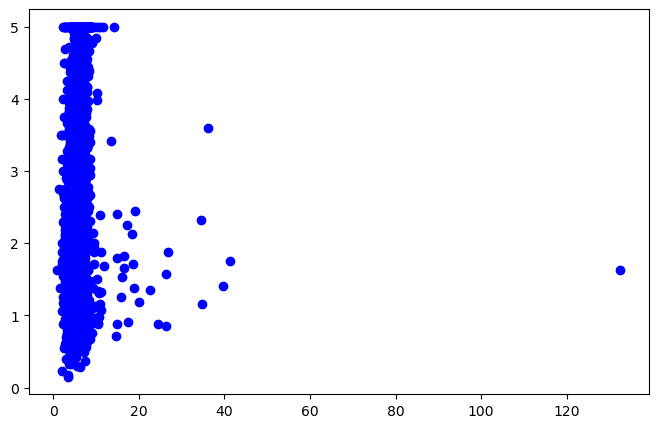

In [69]:
#-------
#Regression Line Visualization
#-------
#sort X values for a smooth line
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
#Scatter plot
plt.scatter(X_test,Y_test,color='blue',label='Actual Data')

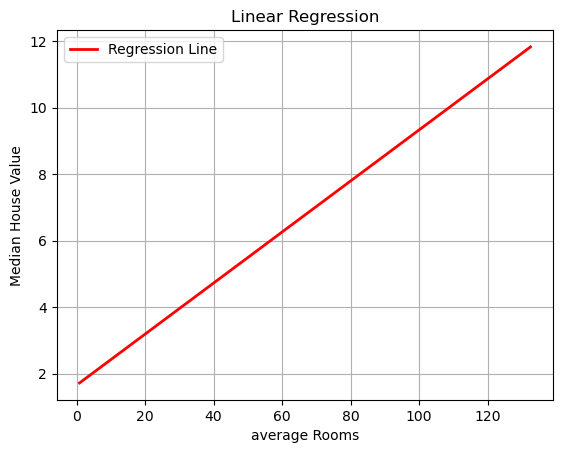

In [70]:
# Regression line
plt.plot(
    X_test.flatten()[index],
    Y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

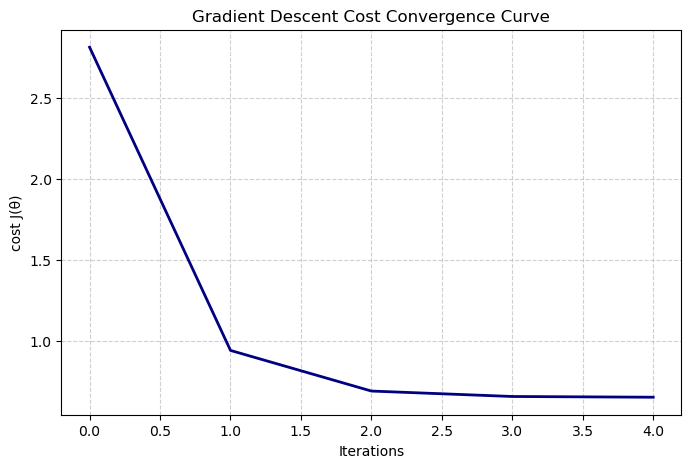

In [71]:
#-----
#Cost Convergence Curve
#----
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('cost J(θ)')
plt.grid(True, linestyle='--',alpha=0.6)
plt.show()